# code for event segmentation procedure

Adapted from Heuser et al., 2018: https://github.com/ContextLab/sherlock-topic-model-paper/blob/master/code/notebooks/main/eventseg_analysis.ipynb

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import brainiak.eventseg.event as event
import pickle
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### some paths

In [2]:
annot_dir = '../../data/annotations_dfs/'
model_dir = '../../data/models/video/t100_w50/'
transc_dir = '../../data/transcriptions/automatic/'
pickle_dir = '../../data/pickles/'

## load episode models

In [67]:
atlep1_model = np.load(model_dir+'/atlep1_model_t100_w50_res.npy')
atlep2_model = np.load(model_dir+'/atlep2_model_t100_w50_res.npy')
arrdev_model = np.load(model_dir+'/arrdev_model_t100_w50_res.npy')
ep_models_dict = {'atlep1': atlep1_model, 'atlep2' : atlep2_model, 'arrdev' : arrdev_model}

## load participant models

In [4]:
with open(pickle_dir+'/participant_models.p', 'rb') as f:
    participant_models = pickle.load(f)

## find optimal k for each episode model

In [5]:
# ep_model_ks = {'atlep1' : [], 'atlep2': [], 'arrdev' : []}

# for ep_model, key in zip([atlep1_model, atlep2_model, arrdev_model], ep_model_ks.keys()):
    
#     corrmat = np.corrcoef(ep_model)
    
#     for n_events in range(1, 51):
#         print('fitting '+ key + ' to ' + str(n_events) + ' events...')
#         ev = event.EventSegment(n_events)
#         ev.fit(ep_model)
#         roundedmat = np.round(ev.segments_[0]).astype(int)
#         mask = np.sum(list(map(lambda x: np.outer(x, x), roundedmat.T)), 0).astype(bool)
#         within = corrmat[mask].mean()
#         across = corrmat[~mask].mean()
#         ep_model_ks[key].append((within, across, within/across))
        

In [6]:
# with open(pickle_dir+'/ep_model_ks.p', 'wb') as f:
#     pickle.dump(ep_model_ks, f)

In [7]:
with open(pickle_dir+'/ep_model_ks.p', 'rb') as f:
    ep_model_ks = pickle.load(f)

## plot within- & across-event correlations as a function of k

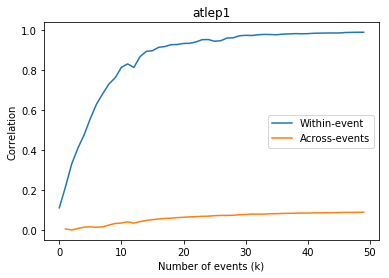

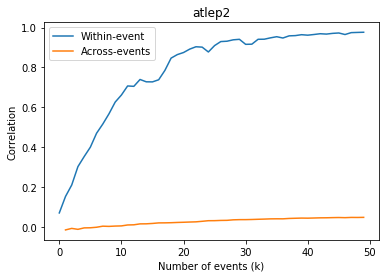

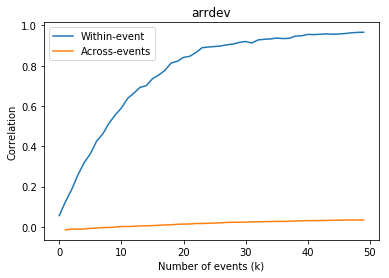

In [8]:
for ep, ks in ep_model_ks.items():
    plt.plot(list(map(lambda x: x[0], ks)), label='Within-event')
    plt.plot(list(map(lambda x: x[1], ks)), label='Across-events')
    plt.title(ep)
    plt.legend()
    plt.xlabel('Number of events (k)')
    plt.ylabel('Correlation')
    plt.show()

In [38]:
# for ep, ks in ep_model_ks.items():
#     plt.plot(list(map(lambda x: x[2], ks)))
#     plt.title(ep)
#     plt.xlabel('Number of events (k)')
#     plt.ylabel('ratio')
#     plt.show()

## plot ratio of within- & across-event correlations as a function of k

atlep1: Max ratio at 32 events


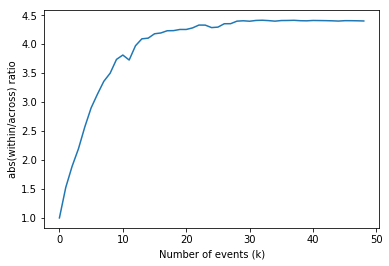

atlep2: Max ratio at 27 events


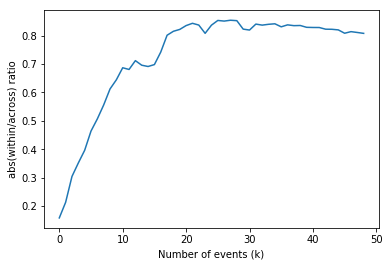

arrdev: Max ratio at 29 events


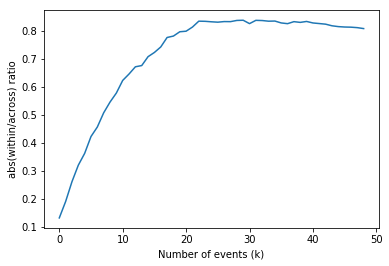

In [72]:
ep_max_ks = []
for ep, ks in ep_model_ks.items():
#     t=list(map(lambda x: x[0]/(x[1]-min(ks[1])), ks))[1:]
    t=list(map(lambda x: x[0]/(x[1]-ks[1][2]), ks))[1:]
    t/=np.max(t)
    
    for i, v in enumerate(t):
        t[i]-=i/250    # regularization parameter (5 x episode_wsize)
    
    plt.plot(t)
    plt.ylabel('abs(within/across) ratio')
    plt.xlabel('Number of events (k)')
    print(ep + ': Max ratio at ' + str(np.argmax(t)) + ' events')
    ep_max_ks.append((ep, np.argmax(t)))
    plt.show()

## fit eventseg model with optimal k to each, save eventseg model, save segmented episode model, save onset/offset times for each event (midpoint time of 1st/last annotation in each event)

In [60]:
def reduce_model(m, ev):
    """
    Reduce a model based on event labels
    """
    w = (np.round(ev.segments_[0])==1).astype(bool)
    return np.array([m[wi, :].mean(0) for wi in w.T])

In [99]:
for ep_name, max_k in ep_max_ks:
    ev = event.EventSegment(max_k)
    ev.fit(ep_models_dict[ep_name])
    episode_events = reduce_model(ep_models_dict[ep_name], ev)
    
    # save episodes' fit eventseg models
    with open(pickle_dir+'/eventseg-models/{}_eventseg_model.p'.format(ep_name), 'wb') as f:
        pickle.dump(ev, f)
    
    # save segmented episode models
    np.save(model_dir+'/{}_events'.format(ep_name), episode_events)
    
    event_onsets_offsets = []
    
    # get onset/offset times
    for s in ev.segments_[0].T:
        tpts = np.where(np.round(s)==1)[0]
        event_onsets_offsets.append((tpts[0], tpts[-1]))
        
    # save onset/offset times
    with open(pickle_dir+'/eventseg-models/{}_event_times.p'.format(ep_name), 'wb') as f:
        pickle.dump(event_onsets_offsets, f)